# Day 08. Exercise 04
# Regression

## 0. Imports

In [1]:
import pandas as pd
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [2]:
csv_path = "../data/checker_regression.csv"
df = pd.read_csv(csv_path)

In [3]:
df = df.drop_duplicates()

In [4]:
df.fillna(0, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 29 entries, 0 to 76
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   uid          29 non-null     object 
 1   num_commits  29 non-null     int64  
 2   pageviews    29 non-null     float64
 3   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1), object(1)
memory usage: 1.1+ KB


In [6]:
X = df[['num_commits', 'pageviews']]
y = df['AVG(diff)']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [8]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=21)
    rmse_train_list = []
    rmse_test_list = []

    for train_idx, test_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_tr, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_tr, y_tr)

        pred_train = model.predict(X_tr)
        pred_test = model.predict(X_val)

        rmse_train = mean_squared_error(y_tr, pred_train, squared=False)
        rmse_test = mean_squared_error(y_val, pred_test, squared=False)

        rmse_train_list.append(rmse_train)
        rmse_test_list.append(rmse_test)

        print(f'train -  {rmse_train}   |   test -  {rmse_test}')

    avg_rmse = np.mean(rmse_test_list)
    print(f'Average RMSE on crossval is {avg_rmse}')

In [9]:
lr = LinearRegression()
crossval(10, X_train, y_train, lr)

train -  53.33351096491692   |   test -  115.2394318363867
train -  62.409919772255556   |   test -  69.35808794733022
train -  64.75146423244131   |   test -  52.395419621714424
train -  64.04094981627755   |   test -  78.18810821407222
train -  63.574089717062186   |   test -  58.669554693832154
train -  65.40154560181439   |   test -  32.10068854674121
train -  64.40600245557161   |   test -  48.59322878192214
train -  61.215472663804725   |   test -  82.41734194163652
train -  64.69372263304507   |   test -  43.81163345544473
train -  62.80195740062014   |   test -  70.47228900535454
Average RMSE on crossval is 65.1245784044435


In [10]:
dt = DecisionTreeRegressor(random_state=21, max_depth=5)
crossval(10, X_train, y_train, dt)

train -  2.4902936573825984   |   test -  43.200154320712016
train -  18.528581525128505   |   test -  77.38312094641445
train -  15.42920121069137   |   test -  9.093266739736606
train -  15.252222710773916   |   test -  8.60313250443633
train -  3.070947882897217   |   test -  80.25661966467314
train -  15.252222710773916   |   test -  15.202795795510772
train -  8.516751700255769   |   test -  40.58792924010783
train -  15.252222710773916   |   test -  37.190388543278225
train -  15.057358587051302   |   test -  50.4874241767195
train -  2.4302777619029476   |   test -  57.982756057296896
Average RMSE on crossval is 41.99875879888857


In [11]:
rf = RandomForestRegressor(random_state=21, n_estimators=100, max_depth=10)
crossval(10, X_train, y_train, rf)

train -  19.85306588532919   |   test -  76.53685427174808
train -  22.671373358544045   |   test -  81.61793883314117
train -  21.694829255044976   |   test -  5.71235319286195
train -  22.7272784086383   |   test -  9.177142450433891
train -  24.38477655695876   |   test -  70.14702143355767
train -  19.90791216218836   |   test -  40.07320878716852
train -  20.52570355431141   |   test -  55.68347292110613
train -  22.325869971584417   |   test -  22.92156316416678
train -  18.972031532693418   |   test -  26.447489505149523
train -  16.687043596636038   |   test -  69.28195592288081
Average RMSE on crossval is 45.759900048221446


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

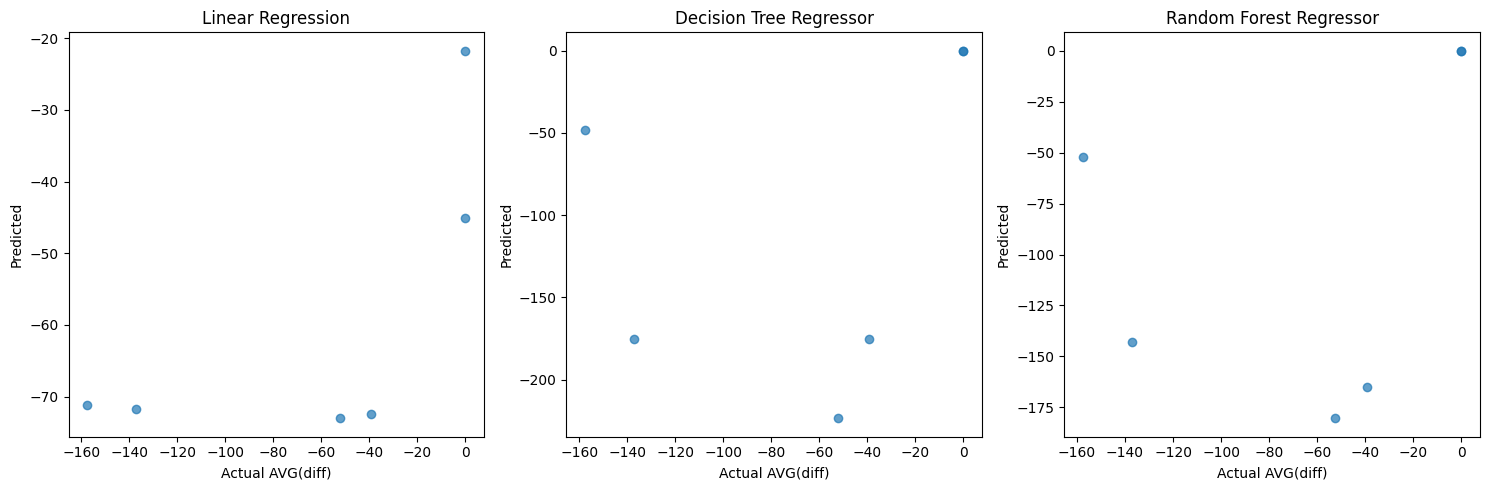

In [12]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.scatter(y_test, lr_pred, alpha=0.7)
plt.title('Linear Regression')
plt.xlabel('Actual AVG(diff)')
plt.ylabel('Predicted')

plt.subplot(1, 3, 2)
plt.scatter(y_test, dt_pred, alpha=0.7)
plt.title('Decision Tree Regressor')
plt.xlabel('Actual AVG(diff)')
plt.ylabel('Predicted')

plt.subplot(1, 3, 3)
plt.scatter(y_test, rf_pred, alpha=0.7)
plt.title('Random Forest Regressor')
plt.xlabel('Actual AVG(diff)')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

## Answer: a diagonal